# Linear Regression

1. What is Linear Regression?

It's a method to model the relationship between a dependent variable and one or more independent variables using a linear equation.
The goal is to find the best-fitting line (or hyperplane in multiple linear regression) that represents the relationship between the variables.
2. Types of Linear Regression:

Simple Linear Regression: Uses only one independent variable to predict the dependent variable.
Multiple Linear Regression: Uses two or more independent variables to predict the dependent variable.
3. Key Concepts & Assumptions:

The relationship between the independent and dependent variables is assumed to be linear.
The errors (residuals) are assumed to be normally distributed with a constant variance.
Independent variables are not highly correlated (multicollinearity).
4. Implementation (Based on the Code):

Import Libraries:
pandas: For data manipulation and analysis.
numpy: For numerical computations.
matplotlib.pyplot: For data visualization.
seaborn: For enhanced data visualization.
sklearn.model_selection.train_test_split: To split the dataset into training and testing sets.
sklearn.linear_model.LinearRegression: To build the linear regression model.
sklearn.metrics: For evaluating the model (e.g., mean_squared_error, r2_score).
Load Data: The code reads data from a CSV file (e.g., "Advertising.csv", "housing_with_ocean_proximity.csv", "Hitters.csv").
Data Exploration: The code uses sns.pairplot to visualize relationships between variables.
Data Preprocessing:
Handling missing values (e.g., filling NaN values in the "Salary" column with the median).
Encoding categorical variables using pd.get_dummies.
Scaling numerical features using StandardScaler.
Splitting Data: The data is split into training and testing sets using train_test_split.
Model Training: A LinearRegression model is created and trained using the training data (lr.fit(X_train, y_train)).
Making Predictions: The trained model is used to make predictions on both the training and testing sets.
Model Evaluation:
The code calculates metrics like Root Mean Squared Error (RMSE) and R-squared to evaluate the model's performance.
The code checks for overfitting and underfitting by comparing training and test set performance.
Regularization: The code demonstrates Lasso (L1) and Ridge (L2) regression to prevent overfitting.
Lasso: Performs feature selection by shrinking some coefficients to zero.
Ridge: Shrinks coefficients but does not force them to zero.
Polynomial Regression: The code shows how to perform polynomial regression, which is a type of non-linear regression.
5. Overfitting and Underfitting:

Overfitting: The model learns the training data too well, including the noise, and performs poorly on unseen data.
Underfitting: The model is too simple to capture the underlying patterns in the data and performs poorly on both training and test data.
Bias-Variance Tradeoff: A key concept is finding the right balance between bias (error due to overly simplistic assumptions) and variance (error due to excessive complexity).
6. Regularization Techniques

Lasso Regression (L1 Regularization): Adds a penalty term proportional to the absolute value of the coefficients to the loss function. This can lead to feature selection by driving some coefficients to zero.
Ridge Regression (L2 Regularization): Adds a penalty term proportional to the square of the coefficients to the loss function. This shrinks the coefficients, reducing the model's complexity and multicollinearity, but it does not perform feature selection.
7. Multicollinearity

Multicollinearity occurs when two or more predictor variables in a multiple regression model are highly correlated.
This can lead to unstable and unreliable estimates of regression coefficients.
The code uses Variance Inflation Factor (VIF) to detect multicollinearity.
8. Non-Linear Regression

Polynomial Regression is used when the relationship between the independent and dependent variables is non-linear.
Polynomial features are created by adding powers of the original features as new features.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # data visualisation library
import seaborn as sns  # data visualization libraray

In [8]:
data=pd.read_csv("Advertising.csv")
data.head(3)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


In [9]:
data.shape

(200, 4)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


a:\python\venv\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


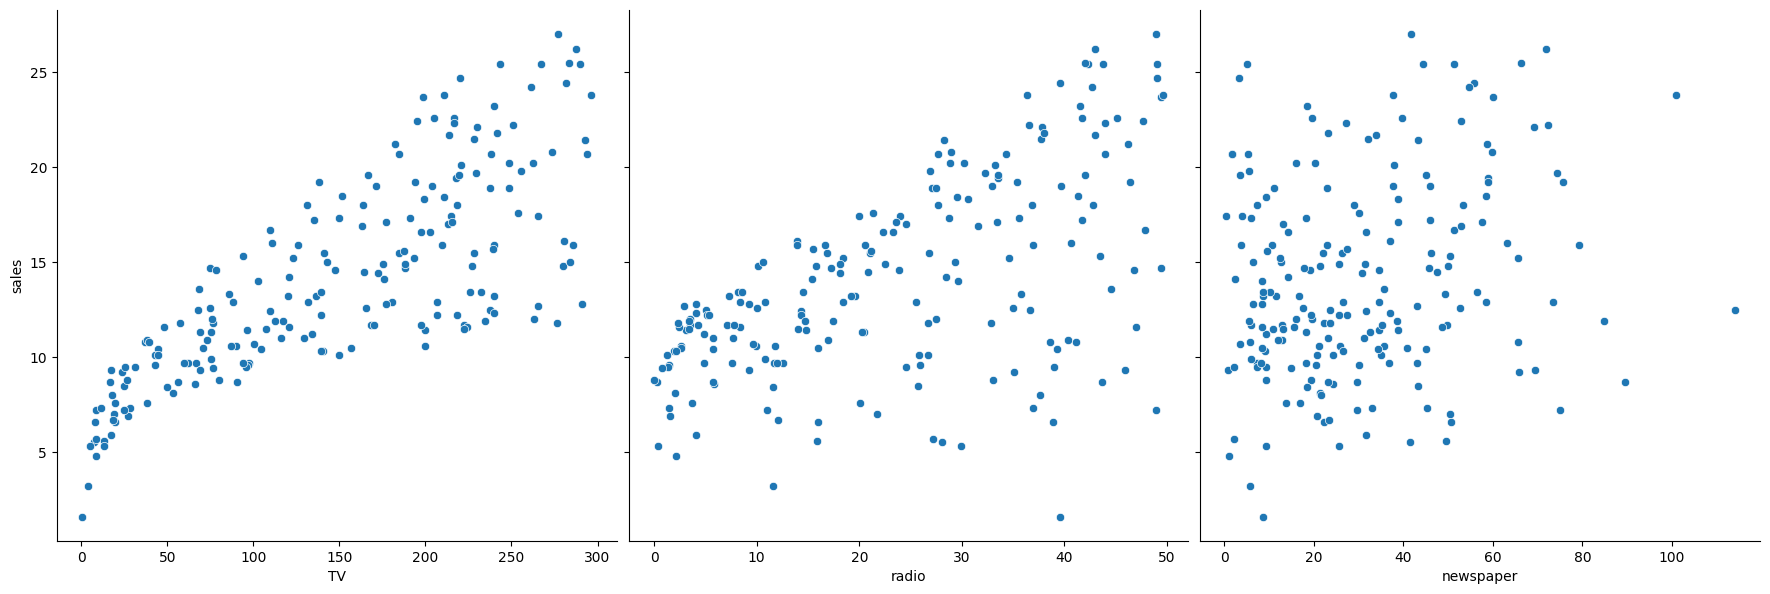

In [11]:
# Plot the data

#sns.pairplot(data)# this will give alll comparison
sns.pairplot(data,x_vars=["TV","radio","newspaper"],y_vars=["sales"],size=6)

In [12]:
# select the feature variable aswell as target variable
# simple Regression discuss 1 feature

X=data.loc[:,["TV"]]  # TV feature
print(X)
y=data.loc[:,["sales"]]  # sale target

        TV
0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
..     ...
195   38.2
196   94.2
197  177.0
198  283.6
199  232.1

[200 rows x 1 columns]


# Split the data as train and test¶


In [13]:
# Scikit learn - conatins all machine laerning library
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)

This line of code uses the train_test_split function from the sklearn.model_selection module to split your dataset into training and testing sets. Here's a breakdown of each argument:

X: This represents the independent variable(s) or feature(s) of your dataset. In the context of your code, X is assigned the "TV" column from the data DataFrame.
y: This represents the dependent variable or target variable that you're trying to predict. In your code, y is assigned the "sales" column from the data DataFrame.
test_size=0.2: This specifies the proportion of the dataset that should be allocated to the test set. In this case, 20% of the data will be used for testing, while the remaining 80% will be used for training.
random_state=20: This sets a seed for the random number generator used to shuffle the data before splitting. Using a constant random_state ensures that the data is split in the same way each time you run the code. This is important for reproducibility

In [14]:
print(X_train.shape)
print(X_train.info)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_test.info)

(160, 1)
<bound method DataFrame.info of         TV
152  197.6
67   139.3
133  219.8
59   210.7
63   102.7
..     ...
148   38.0
137  273.7
156   93.9
15   195.4
99   135.2

[160 rows x 1 columns]>
(40, 1)
(160, 1)
(40, 1)
<bound method DataFrame.info of      sales
150   16.1
28    18.9
13     9.7
178   11.8
109   19.8
168   17.1
177   11.7
196    9.7
47    23.2
195    7.6
136    9.5
77    14.2
187   17.3
166    8.0
84    21.7
175   27.0
155    3.2
167   12.2
121    7.0
192    5.9
176   20.2
113   15.9
89    16.7
147   25.4
185   22.6
143   10.4
199   13.4
126    6.6
5      7.2
97    15.5
34     9.5
139   20.7
44     8.5
72     8.8
183   26.2
85    15.2
149   10.1
46    10.6
86    12.0
112   14.1>


# Training the Simple linear Regression model on Training set


In [15]:
from sklearn.linear_model import LinearRegression # build the Linear Regression model
lr=LinearRegression()

In [16]:
lr.fit(X_train,y_train) # fit the model

LinearRegression()

In [17]:
print("intercept Value",lr.intercept_)

print("The model slope",lr.coef_)

intercept Value [7.29068502]
The model slope [[0.0455393]]


These lines print the intercept and slope of the simple linear regression model that you trained.

lr.intercept_: This attribute of the lr (LinearRegression) object stores the intercept of the regression line. The intercept is the point where the regression line crosses the y-axis. It represents the predicted value of the dependent variable (sales in your case) when the independent variable (TV) is zero.

lr.coef_: This attribute stores the slope (or coefficient) of the regression line. In simple linear regression, there's only one slope because there's only one independent variable. The slope represents the change in the dependent variable (sales) for every one-unit change in the independent variable (TV).

In essence, these lines display the parameters of the linear equation that your model has learned from the training data. The equation takes the form:

sales = lr.coef_ * TV + lr.intercept_


In [18]:
#sales= 0.04 TV+7.29 # 1 unit increase in TV ,the sale will be incraesed by 0.04 times

In [19]:
ypredtrain=lr.predict(X_train)


This line uses the trained linear regression model (lr) to predict the sales values for the TV advertising budgets in the training set (X_train).

lr: This is your trained LinearRegression model. It has learned the relationship between the independent variable (TV advertising budget) and the dependent variable (sales) from the training data.
predict(): This is a method of the LinearRegression object. It takes the independent variable data as input and returns the model's predictions for the dependent variable.
X_train: This is the training data for the independent variable (TV advertising budget). It's a NumPy array or Pandas DataFrame containing the values for which you want to make predictions.
ypredtrain: This variable stores the predicted sales values for the training data. It will be a NumPy array of the same length as X_train, where each element represents the model's prediction for the corresponding TV advertising budget in X_train.
In essence, this line feeds the TV advertising budgets from the training set into the trained linear regression model, and the model outputs its predictions for the corresponding sales values. These predictions are then stored in the ypredtrain variable. This allows you to compare the model's predictions to the actual sales values in the training set, which is useful for evaluating the model's performance and identifying potential issues like overfitting or underfitting.

In [20]:
ypredtrain


array([[16.28925059],
       [13.63430943],
       [17.30022304],
       [16.88581541],
       [11.96757107],
       [18.84855922],
       [17.41862521],
       [17.49148809],
       [18.29753369],
       [ 7.32256253],
       [ 8.37452034],
       [10.00482726],
       [11.86283068],
       [15.09156701],
       [11.31180516],
       [ 9.31718384],
       [16.34845168],
       [10.7698875 ],
       [ 7.82349482],
       [13.26088717],
       [ 8.97108517],
       [18.18823937],
       [17.23646802],
       [18.10171471],
       [15.26461635],
       [17.32299269],
       [17.20459051],
       [10.72890213],
       [10.50575956],
       [13.40661293],
       [20.52895937],
       [11.40743769],
       [ 8.59310898],
       [18.13814615],
       [17.96965074],
       [18.10171471],
       [10.69247069],
       [20.48342007],
       [17.76927782],
       [15.35114102],
       [17.06797261],
       [ 9.49023318],
       [10.33726415],
       [20.62914582],
       [10.43289668],
       [20

In [21]:
ypredtrain=ypredtrain.flatten()
#to convert in one dimenssional array

In [22]:
y_train=np.array(y_train)


In [23]:
y_train=y_train.flatten()


In [24]:
pd.DataFrame({"Actual value":y_train,"Predicted value":ypredtrain})


,Actual value,Predicted value
0,16.6,16.289251
1,13.4,13.634309
2,19.6,17.300223
3,18.4,16.885815
4,14.0,11.967571
...,...,...
155,10.9,9.021178
156,20.8,19.754791
157,15.3,11.566825
158,22.4,16.189064


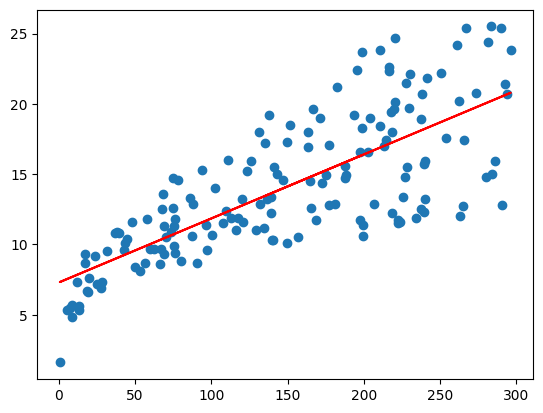

In [25]:
plt.scatter(X_train,y_train)
plt.plot(X_train,ypredtrain,color="red")
plt.show()

In [26]:
from sklearn.metrics import mean_squared_error,r2_score
print("The RMS value for Train data")
print("---------------")
print(np.sqrt(mean_squared_error(y_train,ypredtrain)))

The RMS value for Train data
---------------
3.219665565785585


mean_squared_error(y_train, ypredtrain): This function from sklearn.metrics calculates the Mean Squared Error (MSE) between the actual training values (y_train) and the predicted training values (ypredtrain). MSE is the average of the squared differences between the actual and predicted values.
np.sqrt(...): This function from the numpy library calculates the square root of the MSE. Taking the square root converts the MSE to RMSE, which is more interpretable because it's in the same units as the target variable (sales in this case).
print(...): This function displays the calculated RMSE value in the output.
In summary, this line calculates how far off, on average, your model's predictions are from the actual sales values in the training data. A lower RMSE indicates a better fit of the model to the training data.

In [27]:
ypredtra=r2_score(y_train,ypredtrain)
ypredtra

0.5821664565669462

# Checking for Test Data


In [28]:
ypredtest=lr.predict(X_test)


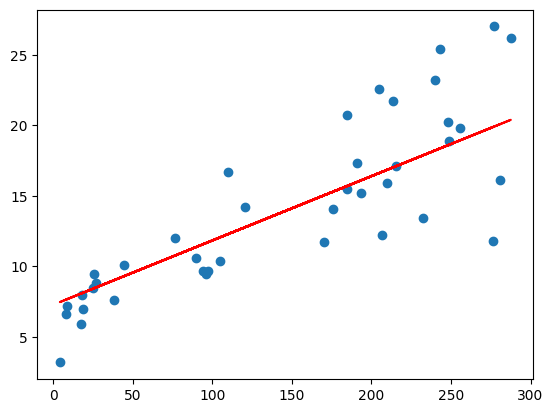

In [29]:
plt.scatter(X_test,y_test)
plt.plot(X_test,ypredtest,color="red")
plt.show()

In [30]:
print("The RMS value for Test data")
print("---------------")
print(np.sqrt(mean_squared_error(y_test,ypredtest)))

The RMS value for Test data
---------------
3.3542374685161116


In [31]:
ypredtes=r2_score(y_test,ypredtest)
ypredtes

0.6891206834040504

# Multiple linear regression


In [32]:
xnew=data.drop([("sales")],axis=1)
ynew=data["sales"]
               

In [33]:
xnew

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [34]:
X_train,X_test,y_train,y_test=train_test_split(xnew,ynew,test_size=0.2,random_state=25)


In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [36]:
mlr=LinearRegression()
mlr.fit(X_train,y_train)

LinearRegression()

In [37]:
print("intercept Value",mlr.intercept_)

print("The model slope",mlr.coef_)

intercept Value 3.1873524943833313
The model slope [ 0.04597936  0.18530829 -0.00522954]


In [38]:
coeff_df=pd.DataFrame(mlr.coef_,X_test.columns,columns=["coefficient"])
coeff_df

,coefficient
TV,0.045979
radio,0.185308
newspaper,-0.005230


In [39]:
#sales= 0.04Tv+0.19 radio-0.002 newspaper+3.25

In [40]:
# 1 unit incraese in TV ,the sale will be incraesed by 0.04 times provided that all other coefficients are constant
# 1 unit incraese in newspaper,the sale will be decreased by 0.002 times provided that all other coefficients are constant

In [41]:
ypredtra_m=mlr.predict(X_train)
ypredtra_m

array([14.15609568, 21.81051968, 21.67301594,  5.55723708, 11.69383285,
        6.16702554, 12.2854516 , 12.5893767 ,  8.23903157, 13.94955693,
        7.80831042,  9.24794549, 13.50400408, 15.47027726,  7.17482143,
       15.27494733, 13.0155976 ,  9.93323735,  3.96669287, 19.81508029,
       16.89108188, 10.02965445, 17.48562467, 23.21797078,  6.82678552,
       20.51985993,  6.67233242, 11.59485472, 17.8098938 ,  9.85151502,
        8.07858899,  9.64501749, 12.89059914, 14.09121835, 18.08302714,
        4.60774971,  6.92766593, 16.51629808, 12.17902776, 16.99530787,
       10.18888377, 13.19634528, 20.65755221, 15.82192967, 20.86802657,
        8.62874661, 11.53128828, 16.6791369 , 12.49086858, 20.4099726 ,
       10.43384279, 18.89388597,  7.80938536, 17.48942528,  7.27815387,
       19.10406802, 19.26559155, 17.20188921, 12.56257777, 10.07224365,
       16.58602145, 18.25811484, 10.44135532, 19.33704166,  9.18506268,
       11.70788311, 23.1723447 , 21.1731045 ,  9.18278136, 15.53

In [42]:
pd.DataFrame({"Actual value":y_train,"Predicted value":ypredtra_m})


,Actual value,Predicted value
165,11.9,14.156096
42,20.7,21.810520
30,21.4,21.673016
195,7.6,5.557237
134,10.8,11.693833
...,...,...
118,15.9,15.390654
61,24.2,22.828368
143,10.4,8.873155
62,15.7,16.919726


In [43]:
print("The RMS value for Train data")
print("---------------")
rmse_tr=np.sqrt(mean_squared_error(y_train,ypredtra_m))
print(rmse_tr)

The RMS value for Train data
---------------
1.6377503355831746


In [44]:
r2_tr=r2_score(y_train,ypredtra_m)
print(r2_tr)

0.9007883778149751


In [45]:
ypredtest_m=mlr.predict(X_test)
ypredtest_m

array([12.3402608 , 14.07319423, 10.24139656, 18.62083195, 23.0146653 ,
       10.48986907, 21.14846855, 16.46529459, 17.26886591, 21.22095393,
       14.40889358, 19.14130606, 14.92056838, 17.83047122, 13.84988859,
       20.09877666,  6.77102512, 18.19008393, 15.46536067, 14.7799973 ,
       13.93489238, 15.121444  , 14.11901217, 21.87393942,  3.72992911,
       15.1366567 , 11.78638346,  9.91585527, 17.31261312, 19.52911589,
       21.10923097, 24.76201831, 11.4009263 , 10.66285002, 14.92503103,
       10.86501665,  8.92720123, 17.81766808, 14.10712318, 18.22320253])

In [46]:
pd.DataFrame({"Actual value":y_test,"Predicted value":ypredtest_m})


,Actual value,Predicted value
148,10.9,12.340261
135,11.6,14.073194
82,11.3,10.241397
193,19.6,18.620832
101,23.8,23.014665
126,6.6,10.489869
69,22.3,21.148469
40,16.6,16.465295
35,12.8,17.268866
111,21.8,21.220954


In [47]:
print("The RMS value for Test data")
print("---------------")
rmse_te=np.sqrt(mean_squared_error(y_test,ypredtest_m))
print(rmse_te)

The RMS value for Test data
---------------
1.8137999591787164


In [48]:
r2_te=r2_score(y_test,ypredtest_m)
print(r2_te)

0.8738569641880866


### Overfitting and Underfitting

When developing machine learning models, achieving the right balance between complexity and simplicity is crucial. This balance is covered in the concepts of overfitting and underfitting.

**Overfitting**

- Overfitting occurs when a model learns the noise and details in the training data too well to the extent that it negatively impacts its performance on new unseen data.
- Sign: High accuracy on training data but poor accuracy on test data.
- Cause: Model is too complex (too many parameters).

**Underfitting**
- Underfitting happens when a model is too simple to capture the underlying pattern of the data.
- Sign: Poor accuracy on both training and test data.
- Cause: Model is too simple (too few parameters).
  
**Bias-Variance Tradeoff**
- Bias: Error due to overly simplistic assumptions in the learning algorithm. High bias can cause underfitting.
- Variance: Error due to excessive complexity in the learning algorithm. High variance can cause overfitting.

**Tradeoff**
- Low Bias & High Variance: Model fits the training data very well but may fail to generalize (overfitting).
- High Bias & Low Variance: Model does not fit the training data well and misses the underlying trend (underfitting).
- Optimal Tradeoff: Finding a balance where the model performs well on both training and test data, minimizing overall error.
  
Understanding and managing the bias-variance tradeoff is key to building models that generalize well to unseen data.

**Let's look at how to check for overfitting or underfitting of the model**

In [49]:
# Print the metrics
print("Training Set Mean Squared Error:",rmse_tr)
print("Test Set Mean Squared Error:", rmse_te)
print("Training Set R² Score:", r2_tr)
print("Test Set R² Score:", r2_te)
print("------------------------------------------")

# Check for overfitting or underfitting
if rmse_tr < rmse_te or r2_tr > r2_te:
    if (r2_tr- r2_te) > 0.05:
        print("Model may be overfitting to the training data.")
    else:
        print("Model performs reasonably well but check for slight overfitting.")
elif rmse_tr > rmse_te and r2_tr < r2_te:
    print("Model may be underfitting, consider increasing model complexity.")
else:
    print("Model has a balanced fit on both training and testing datasets.")

Training Set Mean Squared Error: 1.6377503355831746
Test Set Mean Squared Error: 1.8137999591787164
Training Set R² Score: 0.9007883778149751
Test Set R² Score: 0.8738569641880866
------------------------------------------
Model performs reasonably well but check for slight overfitting.


# Model Evaluation

In [50]:
# Load the dataset
housing_data = pd.read_csv('housing_with_ocean_proximity.csv')

In [51]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [52]:
housing_data.shape

(20640, 10)

In [53]:
housing_data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [54]:
# Remove all the rows with null values:
housing_data = housing_data.dropna()

In [55]:
housing_data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [56]:
housing_data["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [57]:
housing_data = pd.get_dummies(housing_data, drop_first=True, dtype='int',prefix='op')
housing_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,op_INLAND,op_ISLAND,op_NEAR BAY,op_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


# Split the data for Training and Testing

In [58]:
#Assign values to X and y
X = housing_data.drop(['median_house_value'], axis=1)
y = housing_data['median_house_value']

# Splitting the data into training and testing sets to avoid data leakage
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [59]:
from sklearn.model_selection import cross_val_score

lr=LinearRegression()

score=cross_val_score(lr,X,y,cv=7,scoring='r2')

print(score)

r2_avg=score.mean()

print('Avg Score :',r2_avg)

coef_var=score.std()/score.mean()*100

print('The coefficient of Variance :',coef_var)

[0.3566221  0.56876293 0.56658777 0.57917086 0.44468061 0.46836309
 0.73545896]
Avg Score : 0.5313780436340622
The coefficient of Variance : 21.171815636512807


This line calculates the coefficient of variation (CV) of the R-squared scores obtained during cross-validation.

score.std(): This calculates the standard deviation of the R-squared scores stored in the score array. The standard deviation measures the amount of variation or dispersion in the R-squared scores across the different folds of cross-validation.
score.mean(): This calculates the mean (average) of the R-squared scores in the score array.
/: This divides the standard deviation by the mean.
* 100: This multiplies the result by 100 to express the coefficient of variation as a percentage.
coef_var: This variable stores the calculated coefficient of variation.
In essence, the coefficient of variation provides a normalized measure of the dispersion of the R-squared scores relative to their mean. A higher CV indicates greater variability in the R-squared scores across the different cross-validation folds, which might suggest that the model's performance is not consistent across different subsets of the data. A lower CV suggests more consistent performance.

This line uses the cross_val_score function from sklearn.model_selection to perform cross-validation on your linear regression model and evaluate its performance using the R-squared (R²) score. Let's break down each part:

cross_val_score(estimator, X, y, cv, scoring): This function performs cross-validation.
estimator: This is the machine learning model you want to evaluate. In your case, it's lr, which is your LinearRegression model.
X: This is the input data (independent variables) used to train the model. In your case, it represents the features of the housing data.
y: This is the target variable (dependent variable) that you're trying to predict. In your case, it's the median_house_value.
cv: This determines the cross-validation splitting strategy. cv=7 means that the data will be split into 7 folds. The model will be trained on 6 folds and tested on the remaining 1 fold, and this process is repeated 7 times, with each fold serving as the test set once.
scoring: This specifies the metric used to evaluate the model's performance. scoring='r2' indicates that the R-squared score will be used.
score: This variable stores the array of R-squared scores calculated for each of the 7 folds during cross-validation. Each element in the score array represents the R² score obtained when the model was trained on 6 folds and tested on the remaining fold.
In summary, this line performs 7-fold cross-validation using your linear regression model, evaluates the model's performance on each fold using the R-squared score, and stores the resulting R-squared scores in the score variable. This gives you a more robust estimate of how well your model is likely to perform on unseen data compared to a single train/test split.



In [60]:
check=pd.Series([0.53,.56,0.57,0.52,0.59])
r2_avg1=check.mean()

print('Avg Score :',r2_avg1)

coef_var1=check.std()/check.mean()*100

print('The coefficient of Variance :',coef_var1)

Avg Score : 0.554
The coefficient of Variance : 5.200310574327768


In [61]:
# Multicollinearity Check

In [62]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [63]:
vif=[]
for i in range(X.shape[1]):
    vif.append(variance_inflation_factor((X),i))

(pd.DataFrame({'VIF':vif,'Feature':X.columns})).sort_values('VIF',ascending=False)

,VIF,Feature
0,839.988717,longitude
1,814.282157,latitude
4,94.023070,total_bedrooms
6,93.134753,households
3,31.778657,total_rooms
5,16.634555,population
7,9.095218,median_income
2,8.121992,housing_median_age
8,2.722712,op_INLAND
10,1.677025,op_NEAR BAY


This line imports the variance_inflation_factor function from the statsmodels.stats.outliers_influence module. This function is used to calculate the Variance Inflation Factor (VIF) for each independent variable in a multiple linear regression model. VIF is a measure of multicollinearity, which occurs when two or more independent variables in a regression model are highly correlated.

In [64]:
X1=X.drop(["longitude","latitude"],axis=1)
X1

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,op_INLAND,op_ISLAND,op_NEAR BAY,op_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
20635,25.0,1665.0,374.0,845.0,330.0,1.5603,1,0,0,0
20636,18.0,697.0,150.0,356.0,114.0,2.5568,1,0,0,0
20637,17.0,2254.0,485.0,1007.0,433.0,1.7000,1,0,0,0
20638,18.0,1860.0,409.0,741.0,349.0,1.8672,1,0,0,0


In [65]:
vif1=[]
for i in range(X1.shape[1]):
    vif1.append(variance_inflation_factor((X1),i))

(pd.DataFrame({'VIF':vif1,'Feature':X1.columns})).sort_values('VIF',ascending=False)

,VIF,Feature
4,92.728130,households
2,87.825016,total_bedrooms
1,27.781468,total_rooms
3,15.925228,population
5,4.846037,median_income
0,4.180796,housing_median_age
6,1.509335,op_INLAND
8,1.336864,op_NEAR BAY
9,1.257745,op_NEAR OCEAN
7,1.001619,op_ISLAND


In [66]:
X2=X1.drop("households",axis=1)

In [67]:
vif2=[]
for i in range(X2.shape[1]):
    vif2.append(variance_inflation_factor((X2),i))

(pd.DataFrame({'VIF':vif2,'Feature':X2.columns})).sort_values('VIF',ascending=False)

,VIF,Feature
1,27.733114,total_rooms
2,27.522204,total_bedrooms
3,12.055427,population
4,4.803765,median_income
0,4.177520,housing_median_age
5,1.485053,op_INLAND
7,1.333223,op_NEAR BAY
8,1.257720,op_NEAR OCEAN
6,1.001158,op_ISLAND


In [68]:
X3=X2.drop("total_rooms",axis=1)
vif3=[]
for i in range(X3.shape[1]):
    vif3.append(variance_inflation_factor((X3),i))

(pd.DataFrame({'VIF':vif3,'Feature':X3.columns})).sort_values('VIF',ascending=False)


,VIF,Feature
1,11.510331,total_bedrooms
2,11.357184,population
3,3.439342,median_income
0,3.373666,housing_median_age
4,1.465965,op_INLAND
6,1.328505,op_NEAR BAY
7,1.257484,op_NEAR OCEAN
5,1.001154,op_ISLAND


In [69]:
# Forward selection, Backward Elimination,RFE(Recursive feature extraction)

# Regularization

**Regularization in Regression**

In linear regression, regularization encompasses a set of techniques employed to address the issue of overfitting.

**Core Concept**

Regularization techniques achieve their objective by introducing a penalty term to the model's objective function. This objective function, typically measured by mean squared error, is minimized during the training process. The penalty term discourages the model from attaining excessive complexity by penalizing the size of the model coefficients, thereby mitigating overfitting.

**Regularization term** or `alpha`: is a hyperparameter that scales the penalty term. It controls the strength of regularization.
- Higher `alpha`: Imposes a stronger penalty on the coefficients, leading to greater regularization. This tends to produce a simpler model that may underfit the training data but often generalizes better to unseen data.
- Lower `alpha`: Imposes a weaker penalty, leading to a model that is less restricted by the regularization and more complex, potentially capturing more details in the data but at the risk of overfitting.

**Benefits of Regularization**

Enhanced Generalizability: By mitigating overfitting, regularization fosters models that perform well on unseen data.

Reduced Model Complexity: It promotes interpretability and potentially reduces computational costs associated with training complex models.


Common Regularization Techniques are:

* Lasso Regression (L1 Regularization)
* Ridge Regression (L2 Regularization)


## Least Absolute Shrinkage and Selection Operator (Lasso) Regression

**Least Absolute Shrinkage and Selection Operator (Lasso) Regression** relies upon the linear regression model but additionaly performs a so called L1 regularization, which is a process of introducing additional information in order to prevent overfitting. As a consequence, we can fit a model containing all possible predictors and use lasso to perform variable selection by using a technique that regularizes the coefficient estimates (it shrinks the coefficient estimates towards zero).

- It performs variable selection or feature selection.
- It forces some of the coeﬃcient estimates to be exactly equal to zero with the help of a large tuning parameter λ.
- It helps reduce the learning of more complex data and overfitting of the model.
- It decreases the variance of the model without an increase in bias.
  
In particular, the minimization objective does not only include the residual sum of squares (RSS) - like in the OLS regression setting - but also the sum of the absolute value of coefficients.

In [70]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

In [71]:
df = pd.read_csv('Hitters.csv')
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [72]:
df.columns

Index(['Unnamed: 0', 'AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years',
       'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League',
       'Division', 'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

In [73]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [75]:
df["Salary"]=df["Salary"].fillna(df["Salary"].median())

In [76]:
dummies = pd.get_dummies(df[['League', 'Division','NewLeague']])
# Convert boolean True/False to integer 1/0
dummies = dummies.astype(int)
dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   League_A     322 non-null    int64
 1   League_N     322 non-null    int64
 2   Division_E   322 non-null    int64
 3   Division_W   322 non-null    int64
 4   NewLeague_A  322 non-null    int64
 5   NewLeague_N  322 non-null    int64
dtypes: int64(6)
memory usage: 15.2 KB


In [77]:
dummies.head()

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
0,1,0,1,0,1,0
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1


In [78]:
# create label X and y
y = df['Salary']

# drop the column with the outcome variable (Salary), and categorical columns for which dummy variables is already created:
X_numerical = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')

#list of all numerical columns in X_numericals
list_numerical = X_numerical.columns


In [79]:
X_numerical

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
0,293.0,66.0,1.0,30.0,29.0,14.0,1.0,293.0,66.0,1.0,30.0,29.0,14.0,446.0,33.0,20.0
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497.0,127.0,7.0,65.0,48.0,37.0,5.0,2703.0,806.0,32.0,379.0,311.0,138.0,325.0,9.0,3.0
318,492.0,136.0,5.0,76.0,50.0,94.0,12.0,5511.0,1511.0,39.0,897.0,451.0,875.0,313.0,381.0,20.0
319,475.0,126.0,3.0,61.0,43.0,52.0,6.0,1700.0,433.0,7.0,217.0,93.0,146.0,37.0,113.0,7.0
320,573.0,144.0,9.0,85.0,60.0,78.0,8.0,3198.0,857.0,97.0,470.0,420.0,332.0,1314.0,131.0,12.0


In [80]:
#Lasso working fine with scaled data

In [81]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_numerical[list_numerical]=sc.fit_transform(X_numerical)

In [82]:
X_numerical

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
0,-0.574071,-0.755130,-1.123591,-0.804734,-0.728308,-1.145172,-1.310194,-1.015121,-0.997117,-0.795183,-0.985636,-0.905069,-0.923478,0.560399,-0.540924,1.880899
1,-0.430437,-0.431732,-0.433579,-1.035649,-0.383827,0.011930,1.332925,0.344876,0.179704,-0.005697,-0.113299,0.252124,0.430391,1.224048,-0.467740,0.308192
2,0.640293,0.624699,0.831443,0.580752,0.917547,1.724442,-0.903560,-0.441561,-0.398759,-0.075357,-0.404078,-0.192719,0.010354,2.108915,-0.182323,0.937275
3,0.751283,0.861858,1.061447,0.542266,1.147201,-0.080638,0.722974,1.283860,1.312145,1.805477,1.406546,1.526538,0.351634,-0.317331,-0.701928,-0.792703
4,-0.391264,-0.302373,-0.088573,-0.458363,-0.230724,-0.404626,-1.106877,-0.970736,-0.943555,-0.667472,-0.931677,-0.853972,-0.852222,1.841314,-0.489695,-0.635432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,0.757812,0.560020,-0.433579,0.542266,-0.001070,-0.080638,-0.496927,0.023406,0.135325,-0.435270,0.060569,-0.057463,-0.458437,0.128670,-0.716565,-0.792703
318,0.725167,0.754058,-0.663583,0.965609,0.075482,2.557555,0.926291,1.233441,1.214204,-0.353999,1.613389,0.363334,2.305557,0.085854,2.005873,1.880899
319,0.614177,0.538460,-0.893587,0.388323,-0.192448,0.613623,-0.293610,-0.408811,-0.435487,-0.725522,-0.425062,-0.712704,-0.428435,-0.898917,0.044547,-0.163620
320,1.254003,0.926537,-0.203575,1.311981,0.458239,1.817010,0.113024,0.236714,0.213371,0.319386,0.333362,0.270158,0.269127,3.657430,0.176278,0.622733


In [83]:
# Create X with dummy variables and numerical variables
#X = pd.concat([X_numerical, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)
X = pd.concat([X_numerical, dummies], axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        322 non-null    float64
 1   Hits         322 non-null    float64
 2   HmRun        322 non-null    float64
 3   Runs         322 non-null    float64
 4   RBI          322 non-null    float64
 5   Walks        322 non-null    float64
 6   Years        322 non-null    float64
 7   CAtBat       322 non-null    float64
 8   CHits        322 non-null    float64
 9   CHmRun       322 non-null    float64
 10  CRuns        322 non-null    float64
 11  CRBI         322 non-null    float64
 12  CWalks       322 non-null    float64
 13  PutOuts      322 non-null    float64
 14  Assists      322 non-null    float64
 15  Errors       322 non-null    float64
 16  League_A     322 non-null    int64  
 17  League_N     322 non-null    int64  
 18  Division_E   322 non-null    int64  
 19  Division

In [84]:
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks,PutOuts,Assists,Errors,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
0,-0.574071,-0.755130,-1.123591,-0.804734,-0.728308,-1.145172,-1.310194,-1.015121,-0.997117,-0.795183,...,-0.923478,0.560399,-0.540924,1.880899,1,0,1,0,1,0
1,-0.430437,-0.431732,-0.433579,-1.035649,-0.383827,0.011930,1.332925,0.344876,0.179704,-0.005697,...,0.430391,1.224048,-0.467740,0.308192,0,1,0,1,0,1
2,0.640293,0.624699,0.831443,0.580752,0.917547,1.724442,-0.903560,-0.441561,-0.398759,-0.075357,...,0.010354,2.108915,-0.182323,0.937275,1,0,0,1,1,0
3,0.751283,0.861858,1.061447,0.542266,1.147201,-0.080638,0.722974,1.283860,1.312145,1.805477,...,0.351634,-0.317331,-0.701928,-0.792703,0,1,1,0,0,1
4,-0.391264,-0.302373,-0.088573,-0.458363,-0.230724,-0.404626,-1.106877,-0.970736,-0.943555,-0.667472,...,-0.852222,1.841314,-0.489695,-0.635432,0,1,1,0,0,1


In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
# Create and fit the Lasso regression model to the training data
lasso_model = Lasso(alpha=10).fit(X_train, y_train)

print("Lasso intercept:", lasso_model.intercept_)

# Get the coefficients (weights) of the fitted Lasso regression model
print("Lasso coefficients:", lasso_model.coef_)

Lasso intercept: 473.5113448707062
Lasso coefficients: [-0.00000000e+00  5.60827656e+01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  3.68158416e+01 -1.76597549e+01  0.00000000e+00
  5.26979050e+01  0.00000000e+00  0.00000000e+00  1.48389634e+02
 -7.39715817e+00  3.15529548e+01 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00  7.52510470e+01 -1.92588506e-12
 -0.00000000e+00  0.00000000e+00]


In [87]:
# Training data
lasso_model = Lasso(alpha=10).fit(X_train, y_train)
pred_train = lasso_model.predict(X_train)

mse_train = np.sqrt(mean_squared_error(y_train, pred_train))
print('RMSE training set', round(mse_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train)*100,2))
print("---------------------------")

# Test data
pred_test = lasso_model.predict(X_test)
mse_test =np.sqrt(mean_squared_error(y_test, pred_test))
print('RMSE test set', round(mse_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test)*100,2))


RMSE training set 313.91
R squared training set 38.72
---------------------------
RMSE test set 348.01
R squared test set 36.98


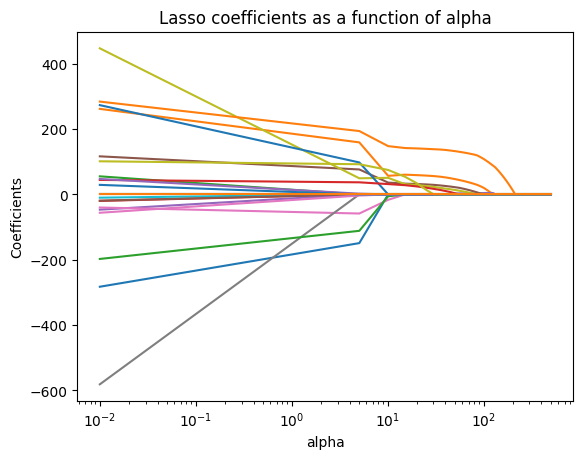

In [88]:
alphas = np.linspace(0.01,500,100)
lasso = Lasso(max_iter=10000)
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Coefficients')
plt.title('Lasso coefficients as a function of alpha');
plt.show()

In [89]:
#lasso_cv_model = LassoCV(alphas = np.random.randint(0, 1000, 100), cv =10, max_iter=10000, n_jobs=-1).fit(X_train, y_train)
lasso_cv_model = LassoCV(alphas = np.random.randint(0, 1000, 100), cv =10, max_iter=10000, n_jobs=-1).fit(X,y)


In [90]:
# Get the best alpha (regularization strength) selected by cross-validation
lasso_cv_model.alpha_

np.int32(16)

In [91]:
lasso_tuned = Lasso(alpha=lasso_cv_model.alpha_, max_iter=10000).fit(X_train, y_train)
#lasso_tuned = Lasso(alpha=lasso_cv_model.alpha_, max_iter=10000).fit(X,y)


In [92]:
# Training data
pred_train_tuned = lasso_tuned.predict(X_train)
mse_train = np.sqrt(mean_squared_error(y_train, pred_train_tuned))
print('RMSE training set post tuning', round(mse_train, 2))
print('R squared training set post tuning', round(r2_score(y_train, pred_train_tuned)*100,2))
print("---------------------------")

# Test data
pred_test_tuned = lasso_tuned.predict(X_test)
mse_test =np.sqrt(mean_squared_error(y_test, pred_test_tuned))
print('RMSE test set post tuning', round(mse_test, 2))
print('R squared test set post tuning', round(r2_score(y_test, pred_test_tuned)*100,2))

RMSE training set post tuning 316.96
R squared training set post tuning 37.52
---------------------------
RMSE test set post tuning 352.16
R squared test set post tuning 35.46


In [93]:
# Create a Pandas Series of the coefficients from the tuned Lasso regression model
pd.Series(lasso_tuned.coef_, index=X_train.columns)

AtBat         -0.000000e+00
Hits           6.014491e+01
HmRun          0.000000e+00
Runs           0.000000e+00
RBI            0.000000e+00
Walks          3.271123e+01
Years         -0.000000e+00
CAtBat         0.000000e+00
CHits          3.085881e+01
CHmRun         0.000000e+00
CRuns          0.000000e+00
CRBI           1.417150e+02
CWalks        -0.000000e+00
PutOuts        2.757087e+01
Assists       -0.000000e+00
Errors        -0.000000e+00
League_A      -0.000000e+00
League_N       0.000000e+00
Division_E     5.059440e+01
Division_W    -1.118713e-12
NewLeague_A   -0.000000e+00
NewLeague_N    0.000000e+00
dtype: float64

### Ridge Regression

Ridge Regression also known as L2 Regularization is a regularization technique used in linear regression to prevent overfitting. It is useful for handling multicollinear data, where two predictors/independent variables are highly correlated to each other.

Collinearity refers to a situation where two or more predictor variables in a multiple regression model are highly correlated, meaning they have a linear relationship. This correlation makes it difficult to determine the individual effect of each predictor on the target variable, leading to unreliable and unstable estimates of regression coefficients.

Ridge regression adds a regularization term to the loss function that penalizes large coefficients in the model and encourages the model to have smaller coefficients. It results in a simpler and more generalized model.

Ridge Regression does shrink the coefficients, it does not force them to zero, meaning it does not perform feature selection

In [94]:
from sklearn.linear_model import Ridge, RidgeCV

In [95]:
# Training data
ridge_model = Ridge(alpha=1).fit(X_train, y_train)
pred_train = ridge_model.predict(X_train)
mse_train = np.sqrt(mean_squared_error(y_train, pred_train))
print('RMSE training set', round(mse_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train)*100,2))
print("---------------------------")

# Test data
pred_test = ridge_model.predict(X_test)
mse_test =np.sqrt(mean_squared_error(y_test, pred_test))
print('RMSE test set', round(mse_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test)*100,2))

RMSE training set 290.51
R squared training set 47.51
---------------------------
RMSE test set 352.82
R squared test set 35.22


In [96]:
ridge_cv_model = RidgeCV(alphas= np.random.randint(0, 1000, 100), cv=10).fit(X,y)

# Get the best alpha (regularization strength) selected by cross-validation
ridge_cv_model.alpha_

np.int32(182)

In [97]:
# Create and fit the ridge regression model using the best alpha found by cross-validation
ridge_tuned = Ridge(alpha=ridge_cv_model.alpha_, max_iter=10000).fit(X_train, y_train)

In [98]:
# Training data
pred_train_tuned = ridge_tuned.predict(X_train)
mse_train = np.sqrt(mean_squared_error(y_train, pred_train_tuned))
print('RMSE training set', round(mse_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train_tuned)*100,2))
print("---------------------------")

# Test data
pred_test_tuned = ridge_tuned.predict(X_test)
mse_test =np.sqrt(mean_squared_error(y_test, pred_test_tuned))
print('RMSE test set', round(mse_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test_tuned)*100,2))

RMSE training set 319.64
R squared training set 36.46
---------------------------
RMSE test set 345.52
R squared test set 37.88


In [99]:
# Create a Pandas Series of the coefficients from the tuned Ridge regression model
pd.Series(ridge_tuned.coef_, index=X_train.columns)

AtBat           1.568642
Hits           28.168820
HmRun           4.992604
Runs           16.998178
RBI            21.644490
Walks          25.977960
Years           0.859559
CAtBat         22.370351
CHits          36.459169
CHmRun         28.759073
CRuns          32.668371
CRBI           37.984280
CWalks          1.834982
PutOuts        27.122635
Assists         2.296707
Errors         -4.116952
League_A       -6.439662
League_N        6.439662
Division_E     23.736827
Division_W    -23.736827
NewLeague_A    -1.789457
NewLeague_N     1.789457
dtype: float64

## Non-linear Regression

Polynomial Regression is a subset of linear regression that includes polynomial terms. The relationship between an independent variable (x) and a dependent variable (y) is modeled as an nth-degree polynomial.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Polynomial.png)

- Polynomial regression is also called as the special case of multiple linear regression. Some polynomial terms are added to the multiple linear regression equation to convert into polynomial regression.
- It is a linear model with some modifications made to increase its accuracy.
- The dataset used in polynomial regression for training is non-linear.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson04_Regression/updates/linear__regression.png)

From the above figure, it is seen that the straight line is unable to capture the patterns in the given data.
To achieve a higher-order equation that captures complex data patterns, the powers of the original features can be added as new features.

The following graph is the result after applying polynomial regression:

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson04_Regression/updates/polynomial__regression.png)

In [100]:
data=pd.read_csv("Advertising.csv")
data.head(3)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


In [101]:
xnew=data[["TV"]]
ynew=data[["sales"]]
               

In [102]:
X_train, X_test, y_train, y_test = train_test_split(xnew, ynew, test_size=0.2, random_state=0)


In [103]:
X_train.shape

(160, 1)

In [104]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [105]:
poly_features = PolynomialFeatures(degree=4)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [106]:
X_train_poly.shape

(160, 5)

In [107]:
y_train_pred = poly_model.predict(X_train_poly)
y_test_pred = poly_model.predict(X_test_poly)

In [108]:
X_range = np.arange(min(np.min(X_train.values), np.min(X_test.values)), 
                    max(np.max(X_train.values), np.max(X_test.values)), 
                    0.1)
X_range = X_range.reshape((len(X_range), 1))

a:\python\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


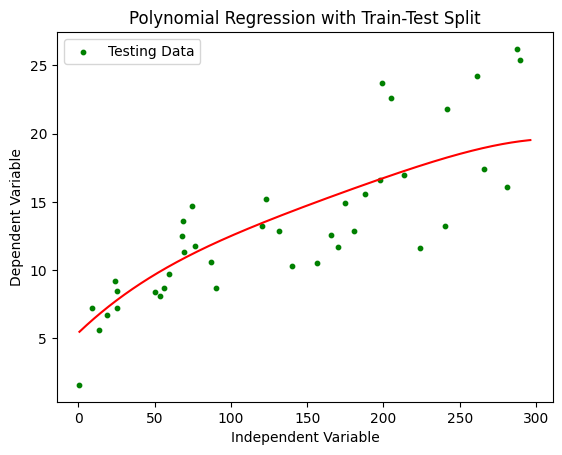

In [109]:
#Plot the results
plt.scatter(X_test, y_test, s=10, label='Testing Data', color='green')
#plt.plot(X_test,y_test_pred)
plt.plot(X_range, poly_model.predict(poly_features.transform(X_range)),color='red')
plt.xlabel('Independent Variable')
plt.ylabel('Dependent Variable')
plt.title('Polynomial Regression with Train-Test Split')
plt.legend()
plt.show()

In [110]:
np.sqrt(mean_squared_error(y_test,y_test_pred))

np.float64(3.2237542524051173)

In [111]:
r2_score(y_test,y_test_pred)

0.669756111278577

In [112]:
# Store the model weight
import pickle

In [113]:
filename="SLdemopolymodel.sav"

In [114]:
pickle.dump(poly_model,open(filename,"wb"))

In [115]:
load_model=pickle.load(open(filename,"rb"))
result=load_model.predict(X_train_poly)


In [116]:
result

array([[ 8.73466826],
       [ 8.31731756],
       [14.43548401],
       [17.11541863],
       [17.33198758],
       [12.63477284],
       [ 6.29653945],
       [ 7.07991977],
       [13.69171748],
       [12.7256911 ],
       [12.97080019],
       [17.83962485],
       [18.62551314],
       [16.15738938],
       [ 9.30355538],
       [10.45957318],
       [19.48589676],
       [15.66015362],
       [16.8453728 ],
       [ 6.16806407],
       [18.93928433],
       [16.65625519],
       [17.44604965],
       [14.62131334],
       [15.61155403],
       [17.41673452],
       [18.87416334],
       [15.29363044],
       [12.52367232],
       [11.2756797 ],
       [16.15738938],
       [14.06741517],
       [19.14323476],
       [19.52760613],
       [12.3176682 ],
       [12.97080019],
       [18.67203584],
       [16.90666061],
       [18.19888378],
       [16.50431489],
       [16.40237855],
       [11.99013824],
       [ 9.18280889],
       [ 8.83218406],
       [ 6.72900074],
       [18

In [117]:
np.sqrt(mean_squared_error(y_train,result))

np.float64(3.201724720198947)

In [118]:
r2_score(y_train,result)

0.6026681059369929